# ML Experiment: Dimensionality Reduction for Phase and Frequency Classification

This notebook compares **PCA** (at various ranks) and **3D t-SNE** (sklearn + KL-optimized out-of-sample projection) as input representations for a **Random Forest**, applied to:

- **Task A**: Phase classification ($\phi = i \bmod 20$, 20 classes)
- **Task B**: $St_{act}$ classification (24 classes)
- **Task C**: Joint $(\phi, St_{act})$ multi-output classification
- **Task D**: Generalization to unseen frequencies (leave-frequencies-out)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os, sys, time, gc, importlib

sys.path.append(os.path.abspath('.'))
import ml_experiment_utils as mlu
importlib.reload(mlu)

plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=12)

os.makedirs('figures', exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load Pre-Computed Global PCA Scores

The file `pca_data/global_forced_pca.npz` contains the global IncrementalPCA scores (500 components) for all 24 forced runs (48,720 snapshots), along with run, $St_{act}$, and phase labels.

In [3]:
# Load pre-computed global PCA scores
data = np.load('pca_data/global_forced_pca.npz')
pca_scores   = data['pca_scores']     # (48720, 500)
run_labels   = data['run_labels']     # (48720,)
st_labels    = data['st_labels']      # (48720,)
phase_labels = data['phase_labels']   # (48720,)

print(f'PCA scores shape: {pca_scores.shape}')
print(f'Unique runs: {np.unique(run_labels)}')
print(f'Unique St values: {len(np.unique(st_labels))} classes')
print(f'Unique phases: {np.unique(phase_labels)}')

PCA scores shape: (48720, 500)
Unique runs: [ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
Unique St values: 24 classes
Unique phases: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


## 2. Train/Test Splits

- **Standard split** (Tasks A, B, C): Stratified 80/20 random split on the combined $(St_{act}, \phi)$ label.
- **Leave-frequencies-out** (Task D): Hold out Runs 4, 10, 16, 22 ($St = 0.15, 0.45, 0.75, 1.05$).

In [4]:
# Standard split
std_train_idx, std_test_idx = mlu.create_standard_split(
    pca_scores, phase_labels, st_labels
)
print(f'Standard split: {len(std_train_idx)} train, {len(std_test_idx)} test')

# Leave-frequencies-out split
lfo_train_idx, lfo_test_idx = mlu.create_leave_freq_out_split(run_labels)
print(f'Leave-freq-out: {len(lfo_train_idx)} train, {len(lfo_test_idx)} test')
print(f'  Held-out St: {[mlu.ST_INFO[r] for r in mlu.HELD_OUT_RUNS]}')

Standard split: 38976 train, 9744 test
Leave-freq-out: 40600 train, 8120 test
  Held-out St: [0.15, 0.45, 0.75, 1.05]


## 3. t-SNE Embedding (sklearn + KL Optimization)

We fit sklearn's t-SNE on the **training PCA scores** to produce a 3D embedding. Test points are then embedded by **fixing all training positions** and individually optimizing each test point's 3D coordinates to minimize the local KL divergence:

$$\min_{\mathbf{y}^*} \sum_j p_{j|*} \log \frac{p_{j|*}}{q_{j|*}}$$

where $p_{j|*}$ are Gaussian affinities in the PCA space (with perplexity-calibrated $\sigma$) and $q_{j|*}$ are Student-t affinities in the 3D embedding.

In [5]:
# t-SNE for the STANDARD split
print('=== Standard Split t-SNE ===')
std_tsne_train, std_tsne_test, std_tsne_fit_t, std_tsne_transform_t = \
    mlu.fit_and_transform_tsne(
        pca_scores[std_train_idx],
        pca_scores[std_test_idx],
        n_components=3, perplexity=50
    )
print(f'Train embedding: {std_tsne_train.shape}')
print(f'Test embedding:  {std_tsne_test.shape}')

=== Standard Split t-SNE ===
Fitting sklearn TSNE (n_components=3, perplexity=50) on 38976 samples with 500 features...
  Fitting completed in 11.5 minutes.
Embedding 9744 test points via optimization (k=50)...
    Embedded 2000/9744 test points...
    Embedded 4000/9744 test points...
    Embedded 6000/9744 test points...
    Embedded 8000/9744 test points...
  Embedding completed in 26.2 seconds.
Train embedding: (38976, 3)
Test embedding:  (9744, 3)


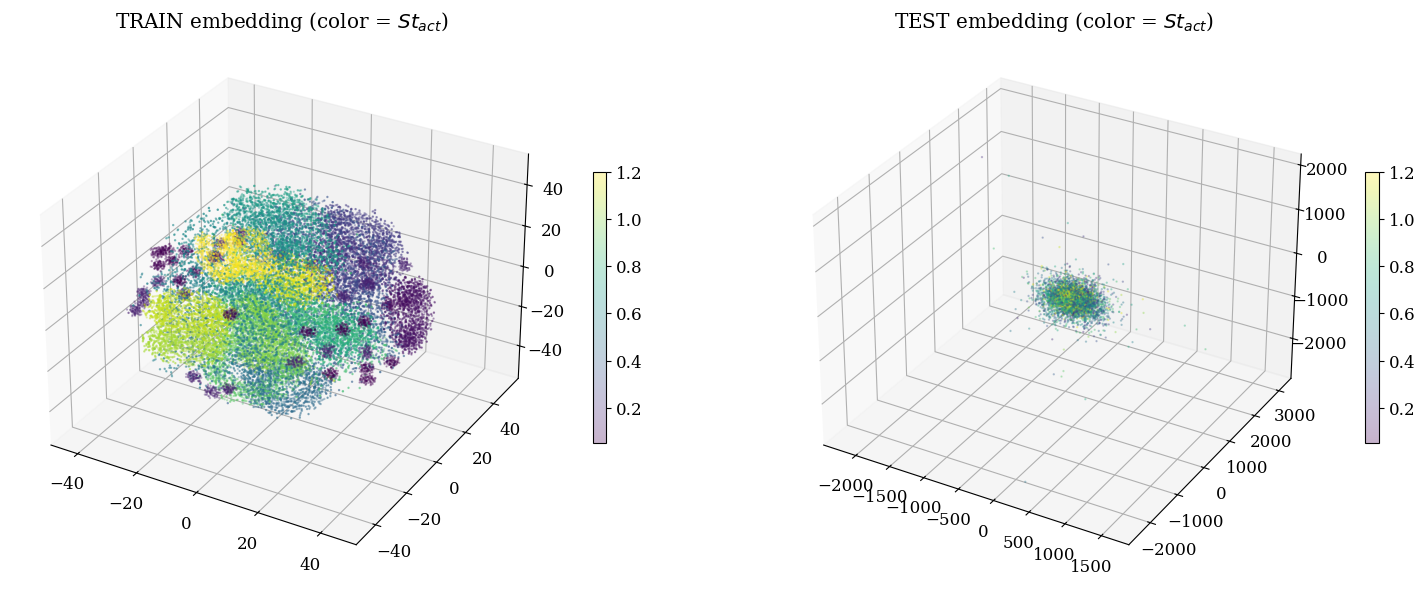

Train range: [-42.8 -45.2 -49.6] to [44.8 51.1 47.6]
Test range:  [-2201.5 -2368.6 -2625.7] to [1596.7 3107.2 1915.4]


In [6]:
# Diagnostic: check that train and test embeddings have structure
fig, axes = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={'projection': '3d'})

ax = axes[0]
sc = ax.scatter(std_tsne_train[:, 0], std_tsne_train[:, 1], std_tsne_train[:, 2],
                c=st_labels[std_train_idx], cmap='viridis', s=0.5, alpha=0.3)
ax.set_title('TRAIN embedding (color = $St_{act}$)')
plt.colorbar(sc, ax=ax, shrink=0.5)

ax = axes[1]
sc = ax.scatter(std_tsne_test[:, 0], std_tsne_test[:, 1], std_tsne_test[:, 2],
                c=st_labels[std_test_idx], cmap='viridis', s=0.5, alpha=0.3)
ax.set_title('TEST embedding (color = $St_{act}$)')
plt.colorbar(sc, ax=ax, shrink=0.5)

plt.tight_layout()
plt.savefig('figures/tsne_diagnostic_standard.png', dpi=300, bbox_inches='tight')
plt.show()

# Coordinate ranges
print(f'Train range: {std_tsne_train.min(axis=0).round(1)} to {std_tsne_train.max(axis=0).round(1)}')
print(f'Test range:  {std_tsne_test.min(axis=0).round(1)} to {std_tsne_test.max(axis=0).round(1)}')

In [7]:
# t-SNE for the LEAVE-FREQUENCIES-OUT split
print('=== Leave-Freq-Out t-SNE ===')
lfo_tsne_train, lfo_tsne_test, lfo_tsne_fit_t, lfo_tsne_transform_t = \
    mlu.fit_and_transform_tsne(
        pca_scores[lfo_train_idx],
        pca_scores[lfo_test_idx],
        n_components=3, perplexity=50
    )
print(f'Train embedding: {lfo_tsne_train.shape}')
print(f'Test embedding:  {lfo_tsne_test.shape}')

=== Leave-Freq-Out t-SNE ===
Fitting sklearn TSNE (n_components=3, perplexity=50) on 40600 samples with 500 features...
  Fitting completed in 16.4 minutes.
Embedding 8120 test points via optimization (k=50)...
    Embedded 2000/8120 test points...
    Embedded 4000/8120 test points...
    Embedded 6000/8120 test points...
    Embedded 8000/8120 test points...
  Embedding completed in 23.3 seconds.
Train embedding: (40600, 3)
Test embedding:  (8120, 3)


## 4. Tasks A, B, C — Standard Classification

For each representation (PCA-10, PCA-50, PCA-100, PCA-200, PCA-500, t-SNE-3D) and each Random Forest complexity level (Low/Medium/High), we train and evaluate three classification tasks.

In [8]:
# Build representations for standard split
std_reps = mlu.build_representations(
    pca_scores[std_train_idx], pca_scores[std_test_idx],
    std_tsne_train, std_tsne_test
)

print('Running Tasks A, B, C...')
std_results = mlu.run_all_standard_experiments(
    std_reps,
    phase_labels[std_train_idx], phase_labels[std_test_idx],
    st_labels[std_train_idx], st_labels[std_test_idx]
)

Running Tasks A, B, C...

  [PCA-10 | Low]  A:0.134  B:0.274  C:0.110
  [PCA-10 | Medium]  A:0.402  B:0.657  C:0.389
  [PCA-10 | High]  A:0.494  B:0.713  C:0.460
  [PCA-50 | Low]  A:0.169  B:0.337  C:0.116
  [PCA-50 | Medium]  A:0.418  B:0.831  C:0.468
  [PCA-50 | High]  A:0.473  B:0.917  C:0.549
  [PCA-100 | Low]  A:0.161  B:0.315  C:0.100
  [PCA-100 | Medium]  A:0.378  B:0.833  C:0.414
  [PCA-100 | High]  A:0.400  B:0.925  C:0.483
  [PCA-200 | Low]  A:0.155  B:0.308  C:0.111
  [PCA-200 | Medium]  A:0.316  B:0.817  C:0.354
  [PCA-200 | High]  A:0.326  B:0.920  C:0.408
  [PCA-500 | Low]  A:0.137  B:0.263  C:0.088
  [PCA-500 | Medium]  A:0.257  B:0.775  C:0.286
  [PCA-500 | High]  A:0.255  B:0.911  C:0.304
  [t-SNE-3D | Low]  A:0.118  B:0.189  C:0.054
  [t-SNE-3D | Medium]  A:0.173  B:0.237  C:0.135
  [t-SNE-3D | High]  A:0.171  B:0.241  C:0.136
Done.


In [9]:
df_std = pd.DataFrame(std_results)
display(df_std.round(4))

,task,representation,complexity,accuracy,f1_macro,train_time,inference_time,inference_time_per_sample,total_nodes,accuracy_phase,accuracy_st,f1_phase,f1_st,exact_match
0,A (Phase),PCA-10,Low,0.1337,0.1516,0.2587,0.0309,0.0000,376,NaN,NaN,NaN,NaN,NaN
1,B (St_act),PCA-10,Low,0.2736,0.2182,0.2533,0.0319,0.0000,502,NaN,NaN,NaN,NaN,NaN
2,C (Joint),PCA-10,Low,NaN,NaN,0.3736,0.1002,0.0000,582,0.1565,0.2560,0.1741,0.2066,0.1103
3,A (Phase),PCA-10,Medium,0.4021,0.4047,6.6857,0.0906,0.0000,213330,NaN,NaN,NaN,NaN,NaN
4,B (St_act),PCA-10,Medium,0.6573,0.6400,6.4241,0.1104,0.0000,477832,NaN,NaN,NaN,NaN,NaN
5,C (Joint),PCA-10,Medium,NaN,NaN,8.6305,0.2028,0.0000,675168,0.4418,0.6506,0.4428,0.6310,0.3894
6,A (Phase),PCA-10,High,0.4943,0.4940,50.5743,0.6854,0.0001,12730176,NaN,NaN,NaN,NaN,NaN
7,B (St_act),PCA-10,High,0.7126,0.6999,39.3634,0.6255,0.0001,8792940,NaN,NaN,NaN,NaN,NaN
8,C (Joint),PCA-10,High,NaN,NaN,60.4663,22.7380,0.0023,14618898,0.4952,0.7137,0.4949,0.7001,0.4596
9,A (Phase),PCA-50,Low,0.1690,0.1705,0.7629,0.0290,0.0000,482,NaN,NaN,NaN,NaN,NaN


## 5. Task D — Generalization to Unseen Frequencies

- **D.1**: $St_{act}$ regression (can the model interpolate unseen frequencies?)
- **D.2**: Phase classification (does phase structure transfer across frequencies?)

In [10]:
# Build representations for leave-frequencies-out split
lfo_reps = mlu.build_representations(
    pca_scores[lfo_train_idx], pca_scores[lfo_test_idx],
    lfo_tsne_train, lfo_tsne_test
)

print('Running Task D (generalization)...')
gen_results = mlu.run_all_generalization_experiments(
    lfo_reps,
    phase_labels[lfo_train_idx], phase_labels[lfo_test_idx],
    st_labels[lfo_train_idx], st_labels[lfo_test_idx]
)

Running Task D (generalization)...

  [PCA-10 | Low]  D1-R2:0.572  D2:0.051
  [PCA-10 | Medium]  D1-R2:0.764  D2:0.061
  [PCA-10 | High]  D1-R2:0.784  D2:0.077
  [PCA-50 | Low]  D1-R2:0.565  D2:0.070
  [PCA-50 | Medium]  D1-R2:0.668  D2:0.096
  [PCA-50 | High]  D1-R2:0.694  D2:0.097
  [PCA-100 | Low]  D1-R2:0.563  D2:0.057
  [PCA-100 | Medium]  D1-R2:0.679  D2:0.080
  [PCA-100 | High]  D1-R2:0.703  D2:0.079
  [PCA-200 | Low]  D1-R2:0.564  D2:0.056
  [PCA-200 | Medium]  D1-R2:0.671  D2:0.081
  [PCA-200 | High]  D1-R2:0.699  D2:0.084
  [PCA-500 | Low]  D1-R2:0.563  D2:0.083
  [PCA-500 | Medium]  D1-R2:0.671  D2:0.080
  [PCA-500 | High]  D1-R2:0.697  D2:0.080
  [t-SNE-3D | Low]  D1-R2:-1.065  D2:0.048
  [t-SNE-3D | Medium]  D1-R2:-0.660  D2:0.043
  [t-SNE-3D | High]  D1-R2:-0.652  D2:0.043
Done.


In [11]:
df_gen = pd.DataFrame(gen_results)
display(df_gen.round(4))

,task,representation,complexity,mae,rmse,r2,train_time,inference_time,inference_time_per_sample,total_nodes,accuracy,f1_macro
0,D.1 (St regression),PCA-10,Low,0.1720,0.2194,0.5723,0.6834,0.0155,0.0000,622,NaN,NaN
1,D.2 (Phase transfer),PCA-10,Low,NaN,NaN,NaN,0.2736,0.0313,0.0000,290,0.0506,0.0289
2,D.1 (St regression),PCA-10,Medium,0.1306,0.1628,0.7644,16.5166,0.0470,0.0000,556556,NaN,NaN
3,D.2 (Phase transfer),PCA-10,Medium,NaN,NaN,NaN,7.3148,0.1584,0.0000,210798,0.0608,0.0611
4,D.1 (St regression),PCA-10,High,0.1251,0.1560,0.7836,103.6537,0.2512,0.0000,8616000,NaN,NaN
5,D.2 (Phase transfer),PCA-10,High,NaN,NaN,NaN,53.8114,0.5137,0.0001,13790972,0.0775,0.0763
6,D.1 (St regression),PCA-50,Low,0.1726,0.2212,0.5652,3.4699,0.0319,0.0000,626,NaN,NaN
7,D.2 (Phase transfer),PCA-50,Low,NaN,NaN,NaN,0.5559,0.0148,0.0000,460,0.0702,0.0618
8,D.1 (St regression),PCA-50,Medium,0.1578,0.1932,0.6681,87.5303,0.0474,0.0000,454746,NaN,NaN
9,D.2 (Phase transfer),PCA-50,Medium,NaN,NaN,NaN,14.5240,0.0956,0.0000,674404,0.0964,0.0969


### Interpretation

*[To be written after examining the results above.]*

## 6. Visualization

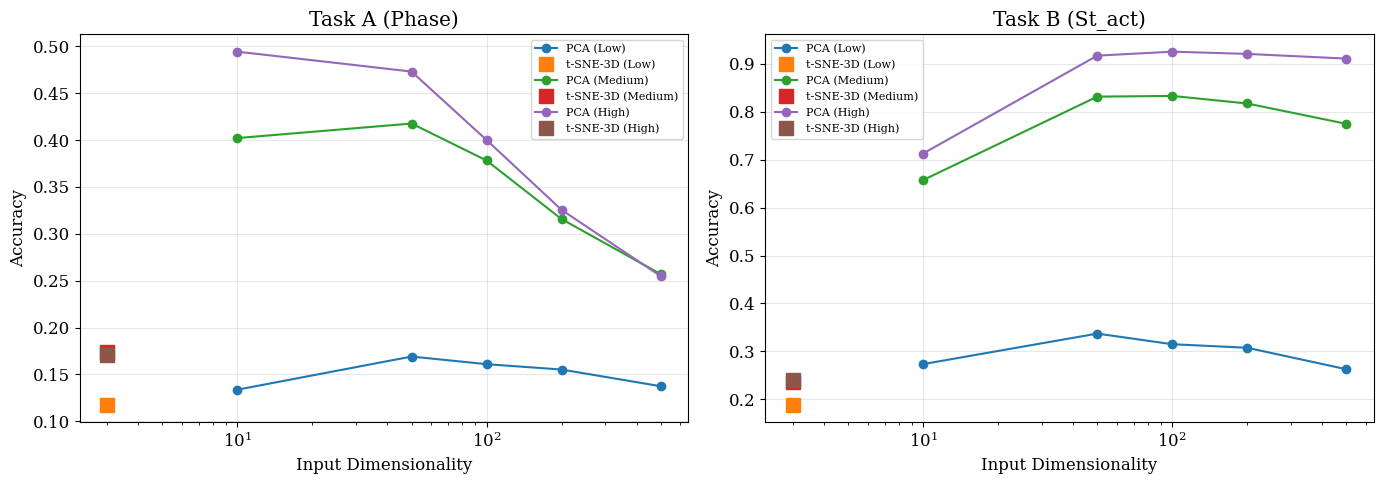

In [12]:
# === Accuracy vs. Dimensionality (Tasks A, B) ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task_name in zip(axes, ['A (Phase)', 'B (St_act)']):
    df_task = df_std[df_std['task'] == task_name]
    for level in ['Low', 'Medium', 'High']:
        df_level = df_task[df_task['complexity'] == level]
        pca_rows = df_level[df_level['representation'].str.startswith('PCA')]
        dims = [int(r.split('-')[1]) for r in pca_rows['representation']]
        ax.plot(dims, pca_rows['accuracy'], 'o-', label=f'PCA ({level})')
        tsne_row = df_level[df_level['representation'] == 't-SNE-3D']
        if len(tsne_row) > 0:
            ax.plot(3, tsne_row['accuracy'].values[0], 's', markersize=10,
                    label=f't-SNE-3D ({level})')
    ax.set_xlabel('Input Dimensionality')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Task {task_name}')
    ax.legend(fontsize=8)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/accuracy_vs_dimensionality.png', dpi=300, bbox_inches='tight')
plt.show()

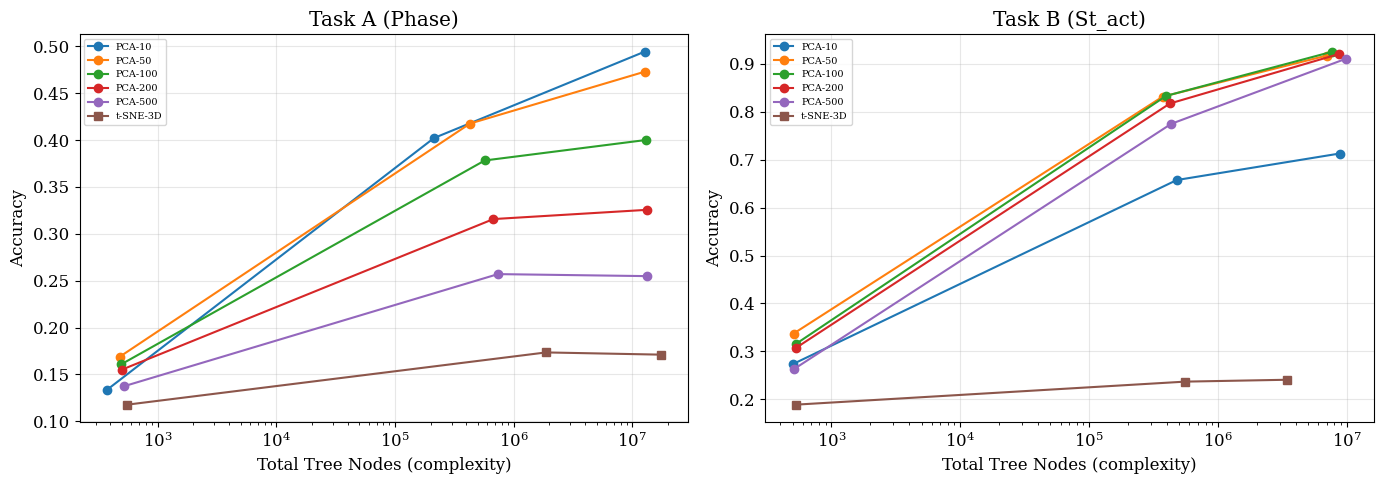

In [13]:
# === Accuracy vs. Model Complexity (total node count) ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task_name in zip(axes, ['A (Phase)', 'B (St_act)']):
    df_task = df_std[df_std['task'] == task_name]
    for rep in df_task['representation'].unique():
        df_rep = df_task[df_task['representation'] == rep]
        marker = 's' if rep == 't-SNE-3D' else 'o'
        ax.plot(df_rep['total_nodes'], df_rep['accuracy'], marker=marker,
                label=rep, markersize=6)
    ax.set_xlabel('Total Tree Nodes (complexity)')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Task {task_name}')
    ax.legend(fontsize=7)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/accuracy_vs_complexity.png', dpi=300, bbox_inches='tight')
plt.show()

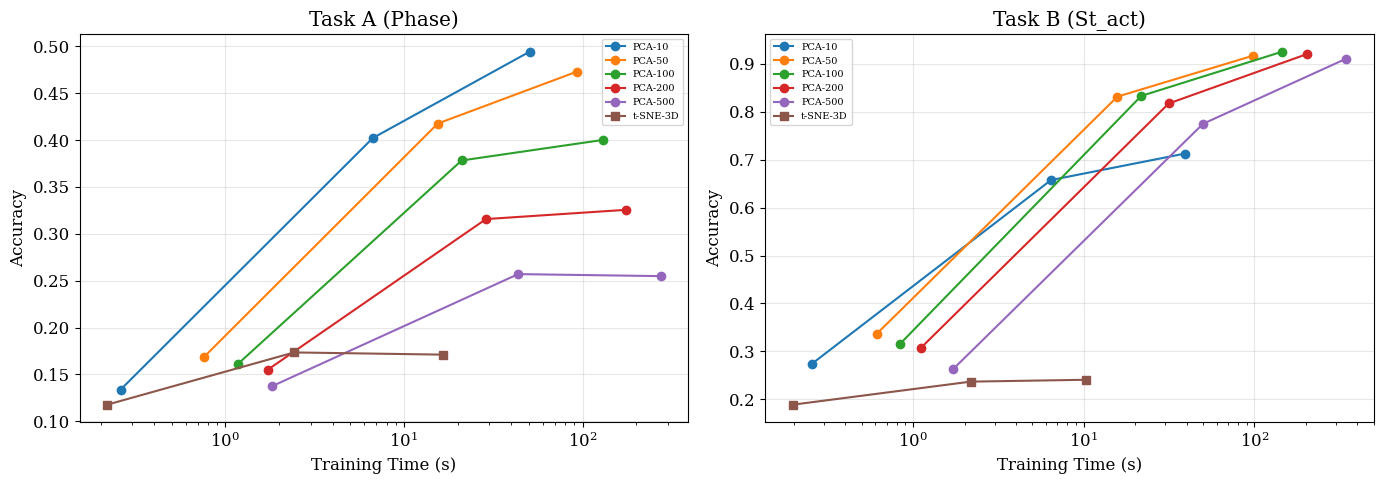

In [14]:
# === Accuracy vs. Training Time ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task_name in zip(axes, ['A (Phase)', 'B (St_act)']):
    df_task = df_std[df_std['task'] == task_name]
    for rep in df_task['representation'].unique():
        df_rep = df_task[df_task['representation'] == rep]
        marker = 's' if rep == 't-SNE-3D' else 'o'
        ax.plot(df_rep['train_time'], df_rep['accuracy'], marker=marker,
                label=rep, markersize=6)
    ax.set_xlabel('Training Time (s)')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Task {task_name}')
    ax.legend(fontsize=7)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/accuracy_vs_training_time.png', dpi=300, bbox_inches='tight')
plt.show()

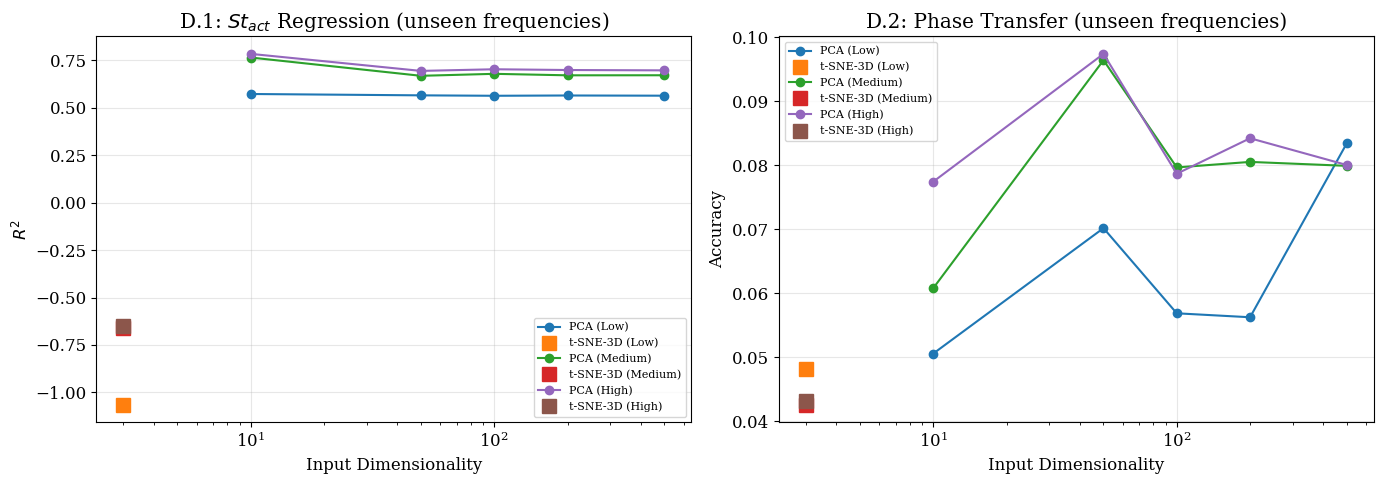

In [15]:
# === Generalization Results ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# D.1: St regression R^2
ax = axes[0]
df_d1 = df_gen[df_gen['task'] == 'D.1 (St regression)']
for level in ['Low', 'Medium', 'High']:
    df_level = df_d1[df_d1['complexity'] == level]
    pca_rows = df_level[df_level['representation'].str.startswith('PCA')]
    dims = [int(r.split('-')[1]) for r in pca_rows['representation']]
    ax.plot(dims, pca_rows['r2'], 'o-', label=f'PCA ({level})')
    tsne_row = df_level[df_level['representation'] == 't-SNE-3D']
    if len(tsne_row) > 0:
        ax.plot(3, tsne_row['r2'].values[0], 's', markersize=10,
                label=f't-SNE-3D ({level})')
ax.set_xlabel('Input Dimensionality')
ax.set_ylabel('$R^2$')
ax.set_title('D.1: $St_{act}$ Regression (unseen frequencies)')
ax.legend(fontsize=8)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# D.2: Phase transfer accuracy
ax = axes[1]
df_d2 = df_gen[df_gen['task'] == 'D.2 (Phase transfer)']
for level in ['Low', 'Medium', 'High']:
    df_level = df_d2[df_d2['complexity'] == level]
    pca_rows = df_level[df_level['representation'].str.startswith('PCA')]
    dims = [int(r.split('-')[1]) for r in pca_rows['representation']]
    ax.plot(dims, pca_rows['accuracy'], 'o-', label=f'PCA ({level})')
    tsne_row = df_level[df_level['representation'] == 't-SNE-3D']
    if len(tsne_row) > 0:
        ax.plot(3, tsne_row['accuracy'].values[0], 's', markersize=10,
                label=f't-SNE-3D ({level})')
ax.set_xlabel('Input Dimensionality')
ax.set_ylabel('Accuracy')
ax.set_title('D.2: Phase Transfer (unseen frequencies)')
ax.legend(fontsize=8)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/generalization_results.png', dpi=300, bbox_inches='tight')
plt.show()

# ML Classification Experiment — PCA vs t-SNE Analysis

Analysis of the results from `ml_classification_experiment.ipynb`, which evaluates PCA (at ranks 10, 50, 100, 200, 500) and 3D t-SNE (sklearn + KL-optimized out-of-sample projection) as input representations for Random Forest classifiers on four tasks.

---

## 1. Accuracy vs. Dimensionality

![Accuracy vs Dimensionality](file:///f:/TFG_datos/code/figures/accuracy_vs_dimensionality.png)

**Task A (Phase classification, 20 classes):**
- **PCA-10 is the best representation** at High RF complexity (~49% accuracy).
- Accuracy **decreases monotonically** as more PCA components are added (PCA-50 → PCA-500).
- This is a strong signal: the phase-discriminative information is concentrated in the first ~10 modes (the large-scale coherent vortex structures driven by the actuation), and higher PCA modes add turbulent noise that confuses the classifier.

**Task B ($St_{act}$ classification, 24 classes):**
- **PCA-50 is optimal** (~92% at High complexity).
- PCA-10 is clearly insufficient (~72%), while PCA-100 to PCA-500 slightly underperform PCA-50.
- Frequency discrimination requires more modes than phase — likely because distinguishing nearby $St$ values requires resolving finer differences in the spatial structure of the velocity field.

**t-SNE-3D:**
- Consistently at or below chance level for both tasks (~12–18% for phase, ~20–25% for $St_{act}$).
- The KL-optimized out-of-sample embedding failed completely.

---

## 2. t-SNE Diagnostic — The Smoking Gun

![t-SNE Diagnostic](file:///f:/TFG_datos/code/figures/tsne_diagnostic_standard.png)

This diagnostic plot reveals **why** t-SNE classification fails:

- The **training embedding** (left) spans $\pm 40$ in all axes and shows clear $St_{act}$ color clustering — the embedding itself is structured.
- The **test embedding** (right) collapses into a tiny blob at scale $\pm 2000$, with no visible structure. The coordinates are two orders of magnitude larger than training.

The KL-optimized out-of-sample projection is **catastrophically unstable**: the L-BFGS-B optimizer for each test point finds a local minimum that does not preserve the global topology of the training embedding. Test points are placed at wildly incorrect coordinates.

> [!IMPORTANT]
> This confirms that t-SNE — even with principled KL-divergence optimization for out-of-sample points — is fundamentally unsuitable for inductive tasks. It is strictly a transductive visualization tool.

---

## 3. Accuracy vs. Model Complexity

![Accuracy vs Complexity](file:///f:/TFG_datos/code/figures/accuracy_vs_complexity.png)

- For both tasks, accuracy scales **log-linearly** with total tree node count.
- **PCA-10 is the most efficient** representation: it reaches the Pareto frontier first (highest accuracy per unit of model complexity).
- PCA-50 eventually catches up at High complexity for $St_{act}$, but requires ~100× more tree nodes.
- t-SNE remains flat at chance regardless of how much complexity is added — confirming the issue is in the representation, not the model capacity.

---

## 4. Accuracy vs. Training Time

![Accuracy vs Training Time](file:///f:/TFG_datos/code/figures/accuracy_vs_training_time.png)

- The **Pareto-optimal** representations are PCA-10 (for phase) and PCA-50 (for $St_{act}$).
- PCA-500 is the slowest (200+ seconds at High complexity) and delivers the **worst** accuracy among PCA variants — confirming that the curse of dimensionality dominates for this dataset size (~39,000 training samples).
- t-SNE is computationally cheap (only 3 features) but provides no useful accuracy.

---

## 5. Generalization to Unseen Frequencies (Task D)

![Generalization Results](file:///f:/TFG_datos/code/figures/generalization_results.png)

**D.1 — $St_{act}$ Regression ($R^2$):**
- PCA achieves $R^2 \approx 0.55$–$0.77$ across all dimensionalities, with Medium/High RF performing best.
- **Dimensionality barely matters** — even PCA-10 gives $R^2 = 0.57$. The first 10 PCA modes already encode $St_{act}$ as a smooth, continuous parameter.
- t-SNE gives $R^2 < -0.6$ (predictions are worse than guessing the mean).

**D.2 — Phase Transfer (Accuracy):**
- All models are near chance (~5–9%), including all PCA variants.
- **Phase structure does not transfer** across unseen frequencies. This is physically correct: the same phase angle within the actuation cycle produces geometrically different vortex patterns at different $St_{act}$ values (different vortex spacing, size, and convection velocity).

---

## Summary Table

| Finding | Implication |
|---------|-------------|
| PCA-10 best for phase, PCA-50 best for $St_{act}$ | Phase lives in ~10 modes, frequency needs ~50 |
| Accuracy drops at high PCA dimensions | Higher modes capture turbulent noise, not discriminative signal |
| t-SNE test embedding collapses (scale mismatch) | Out-of-sample t-SNE is fundamentally unreliable, even with KL optimization |
| $St_{act}$ generalizes ($R^2 \approx 0.75$) | The flow manifold is smooth and continuous in the frequency direction |
| Phase does not generalize (~5%) | Phase structure is frequency-specific: same $\phi$, different spatial pattern |
| More RF complexity always helps | The bottleneck is representation quality, not model capacity |
